# Kwartieranalyse — Energie per 15 minuten

Dit notebook analyseert alle energiemetingen op kwartiersniveau (15 min).
De **Fluvius digitale meter** levert de basis: één lijn per kwartier met afname en injectie,
aangevuld met een tarief-indicator (dag/nacht) en data uit alle overige bronnen.


In [8]:
import sys
from pathlib import Path

# Projectroot op sys.path zodat scripts-pakket vindbaar is
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import scripts.overall as overall
import scripts.fluvius as fluvius
from scripts.owndev import OVERALL_FILE


## 1. Bouw het kwartierbestand

`overall.bouw()` laadt de Fluvius-data als basis, bepaalt het tarief (dag/nacht) per kwartier
en verrijkt met OwnDev, SolarLogs, Battery, Solarcharge en weerdata.
Het resultaat wordt opgeslagen in `data/Final/overall.csv`.


In [9]:
importlib.reload(overall)

df, pad = overall.bouw()
print(f'Opgeslagen: {pad}')
print(f'Kwartieren : {len(df)}')
print(f'Kolommen   : {list(df.columns)}')
df.head()


Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\overall.csv
Kwartieren : 50104
Kolommen   : ['kwartier', 'afname_kwh', 'injectie_kwh', 'tarief', 'fl_afname_dag', 'fl_afname_nacht', 'fl_injectie_dag', 'fl_injectie_nacht', 'bat_laden_kw', 'bat_ontladen_kw', 'afname_kw', 'terugave_kw', 'soc_begin', 'soc_eind', 'n_seconden', 'sl_afname_kwh', 'sl_injectie_kwh', 'sl_productie_kwh', 'bat_geladen_kwh', 'bat_ontladen_kwh', 'bat_soc_uur', 'weer_poa_w_m2', 'weer_ghi_w_m2', 'weer_zon_min', 'ev_energie_kwh', 'ev_vermogen_kw']


,kwartier,afname_kwh,injectie_kwh,tarief,fl_afname_dag,fl_afname_nacht,fl_injectie_dag,fl_injectie_nacht,bat_laden_kw,bat_ontladen_kw,...,sl_injectie_kwh,sl_productie_kwh,bat_geladen_kwh,bat_ontladen_kwh,bat_soc_uur,weer_poa_w_m2,weer_ghi_w_m2,weer_zon_min,ev_energie_kwh,ev_vermogen_kw
0,2024-11-01 00:00:00,0.229,0.009,nacht,0.0,0.229,0.0,0.009,NaN,NaN,...,0.0,0.0,1.0,0.0,12.0,0.0,0.0,0.0,NaN,NaN
1,2024-11-01 00:15:00,0.642,0.000,nacht,0.0,0.642,0.0,0.000,NaN,NaN,...,0.0,0.0,1.0,0.0,12.0,0.0,0.0,0.0,NaN,NaN
2,2024-11-01 00:30:00,0.574,0.000,nacht,0.0,0.574,0.0,0.000,NaN,NaN,...,0.0,0.0,1.0,0.0,12.0,0.0,0.0,0.0,NaN,NaN
3,2024-11-01 00:45:00,0.363,0.000,nacht,0.0,0.363,0.0,0.000,NaN,NaN,...,0.0,0.0,1.0,0.0,12.0,0.0,0.0,0.0,NaN,NaN
4,2024-11-01 01:00:00,0.390,0.000,nacht,0.0,0.390,0.0,0.000,NaN,NaN,...,0.0,0.0,1.0,0.0,21.0,0.0,0.0,0.0,NaN,NaN


## 2. Structuur en basisstatistieken

Overzicht van de data: datatypes, periode en beschrijvende statistieken.


In [10]:
print('Periode:', df['kwartier'].min(), '→', df['kwartier'].max())
print('Kwartieren:', len(df))
print()
print('Tariefsplitsing:')
print(df['tarief'].value_counts().to_string())
print()
df.describe(include='all').round(3)


Periode: 2024-11-01 00:00:00 → 2026-04-06 23:45:00
Kwartieren: 50104

Tariefsplitsing:
tarief
nacht    28959
dag      21145



,kwartier,afname_kwh,injectie_kwh,tarief,fl_afname_dag,fl_afname_nacht,fl_injectie_dag,fl_injectie_nacht,bat_laden_kw,bat_ontladen_kw,...,sl_injectie_kwh,sl_productie_kwh,bat_geladen_kwh,bat_ontladen_kwh,bat_soc_uur,weer_poa_w_m2,weer_ghi_w_m2,weer_zon_min,ev_energie_kwh,ev_vermogen_kw
count,50104,50104.000,50104.000,50104,50104.000,50104.000,50104.000,50104.000,805.000,805.000,...,50104.000,50104.0,46376.000,46376.000,46376.000,50104.000,50104.000,50104.000,5729.000,5729.000
unique,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,nacht,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,28959,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-07-19 23:36:22.891585,0.231,0.005,NaN,0.069,0.162,0.004,0.002,0.102,0.085,...,0.020,0.0,0.169,0.156,18.622,99.234,118.082,17.506,0.604,2.411
min,2024-11-01 00:00:00,0.000,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.0,-1.000,0.000,0.000,0.000,0.000,0.000,0.002,0.007
25%,2025-03-11 11:26:15,0.025,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.495,1.979
50%,2025-07-19 23:52:30,0.138,0.000,NaN,0.000,0.008,0.000,0.000,0.000,0.000,...,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.560,2.238
75%,2025-11-27 11:18:45,0.301,0.001,NaN,0.041,0.198,0.000,0.000,0.010,0.000,...,0.010,0.0,0.000,0.000,25.000,77.700,165.000,60.000,0.671,2.685
max,2026-04-06 23:45:00,2.080,0.638,NaN,1.779,2.080,0.638,0.616,2.364,2.429,...,2.130,0.0,8.000,4.000,100.000,923.520,889.000,60.000,3.262,13.047


## 3. Analyse van de beschikbare data

Overzicht van de meetperiode en het aantal dagen waarop elke bron
effectief data heeft geleverd.


In [11]:
import pandas as pd

# Datum-kolom aanmaken
df['datum'] = pd.to_datetime(df['kwartier']).dt.date

# ── Periodeinfo ────────────────────────────────────────────────────────────
begindatum  = df['datum'].min()
einddatum   = df['datum'].max()
alle_dagen  = pd.date_range(begindatum, einddatum, freq='D')
n_alle_dagen = len(alle_dagen)

# ── Dagen met meting per bron ──────────────────────────────────────────────
# iLumen batterij: bat_geladen_kwh of bat_ontladen_kwh aanwezig (niet NaN en > 0)
dagen_ilumen_bat = (
    df[df['bat_geladen_kwh'].notna() | df['bat_ontladen_kwh'].notna()]
    ['datum'].nunique()
)

# iLumen SolarLogs: sl_productie_kwh aanwezig
dagen_ilumen_sol = (
    df[df['sl_productie_kwh'].notna()]
    ['datum'].nunique()
)

# OwnDev: n_seconden aanwezig (er is minstens één kwartier met secondedata)
dagen_owndev = (
    df[df['n_seconden'].notna()]
    ['datum'].nunique()
)

# Zon: minstens één kwartier in de dag met zonneschijn > 0
dagen_zon = (
    df[df['weer_zon_min'].fillna(0) > 0]
    ['datum'].nunique()
)

# Zon: gemiddeld aantal uur zon op dagen dat er zon was
zon_per_dag = (
    df.groupby('datum')['weer_zon_min']
    .apply(lambda x: x.fillna(0).sum() / 4 / 60)   # kwartier -> uur
)
gem_zon_op_zondagen = zon_per_dag[zon_per_dag > 0].mean()
totale_zon_uren = zon_per_dag.sum()

# ── Rapport ────────────────────────────────────────────────────────────────
print('=' * 52)
print('  DATA-ANALYSE KWARTIERBESTAND')
print('=' * 52)
print(f'  Begindatum              : {begindatum}')
print(f'  Einddatum               : {einddatum}')
print(f'  Totaal aantal dagen     : {n_alle_dagen}')
print()
print('  MEETDAGEN PER BRON')
print(f'  {"Bron":<30} {"dagen":>5}  {"van":>5}')
print('  ' + '-' * 44)
print(f'  {"iLumen batterij":<30} {dagen_ilumen_bat:>5}  {n_alle_dagen:>5}')
print(f'  {"iLumen SolarLogs":<30} {dagen_ilumen_sol:>5}  {n_alle_dagen:>5}')
print(f'  {"OwnDev (P1 + SOFAR)":<30} {dagen_owndev:>5}  {n_alle_dagen:>5}')
print()
print('  ZONNESCHIJN')
print(f'  Dagen met zonneschijn   : {dagen_zon}  van  {n_alle_dagen}')
print(f'  Totale zonneschijn      : {totale_zon_uren:.1f} uur')
print(f'  Gem. zon op zondagen    : {gem_zon_op_zondagen:.1f} uur/dag')
print('=' * 52)


  DATA-ANALYSE KWARTIERBESTAND
  Begindatum              : 2024-11-01
  Einddatum               : 2026-04-06
  Totaal aantal dagen     : 522

  MEETDAGEN PER BRON
  Bron                           dagen    van
  --------------------------------------------
  iLumen batterij                  492    522
  iLumen SolarLogs                 522    522
  OwnDev (P1 + SOFAR)                9    522

  ZONNESCHIJN
  Dagen met zonneschijn   : 465  van  522
  Totale zonneschijn      : 3654.7 uur
  Gem. zon op zondagen    : 7.9 uur/dag


## 4. Verbruiksanalyse: EV en zonnepanelen buiten beschouwing

### Methodologie

De ruwe Fluvius-data (`afname_kwh`, `injectie_kwh`) beschrijft de wisselwerking
met het distributienet. Die meting is echter vertekend door twee grote variabele
elementen:

1. **EV-lading**: het opladen van de wagen verhoogt de afname sterk tijdens laadsessies,
   maar is geen \'huishoudelijk\' verbruik. Door `ev_energie_kwh` af te trekken van
   de afname, bekomt men de netafname exclusief wagenladen.

2. **Zonnepanelen**: de installatie produceert energie die deels direct verbruikt wordt
   (zelfconsumptie) en deels op het net gezet wordt (injectie). Dat maakt de Fluvius-
   meting seizoensgebonden: in de zomer lijkt het huis minder van het net te nemen,
   maar het verbruikt misschien evenveel. Om het **werkelijke huisverbruik** te
   reconstrueren, telt men de lokale productie er bij op en trekt men de injectie eraf:

   ```
   verbruik_totaal = afname_kwh + productie_kwartier - injectie_kwh - ev_kwh
   ```

   Waarbij `productie_kwartier = sl_productie_kwh / 4` (SolarLogs levert uurwaarden;
   we verdelen die gelijkmatig over de vier kwartieren van elk uur).

Het resultaat is een verbruikscijfer dat onafhankelijk is van zowel het EV-laden als
van de opbrengst van de zonnepanelen en dat het effectieve verbruik van het gebouw
representeert.


In [12]:
import numpy as np
import pandas as pd

# ── Hulpkolommen op kwartiersniveau ───────────────────────────────────────
# EV: NaN = geen laadsessie
df['ev_kwh'] = df['ev_energie_kwh'].fillna(0)

# Batterijcorrectie:
#   OwnDev geeft gemiddeld vermogen (kW) per kwartier → kWh = kW * 0.25
#   Als OwnDev ontbreekt, valt men terug op iLumen-uurwaarden (/4).
def bat_kwh(kw_col, kwh_col):
    """kW * 0.25 als beschikbaar, anders uurkwh / 4, anders 0."""
    od  = df[kw_col].fillna(0)  * 0.25
    il  = df[kwh_col].fillna(0) / 4
    # Gebruik OwnDev waar aanwezig, anders iLumen
    return od.where(df[kw_col].notna(), il)

df['bat_ontladen_kwh_kw'] = bat_kwh('bat_ontladen_kw', 'bat_ontladen_kwh')
df['bat_laden_kwh_kw']    = bat_kwh('bat_laden_kw',    'bat_geladen_kwh')

# ── Verbruik per kwartier ─────────────────────────────────────────────────
# Energiebalans per kwartier:
#   Wat het huis verbruikt = afname van net
#                          + batterijontlading (extra energie beschikbaar)
#                          - injectie naar net (zon-surplus)
#                          - EV-laden
#                          - batterijlading (energie opgeslagen, niet verbruikt)
#
# Dit geeft het werkelijke huisverbruik exclusief EV en batterijherverdeling.
# Negatieve waarden zijn mathematisch mogelijk maar fysisch uitzonderlijk
# (duidt op meetruis of tijdsverschil tussen metingen).
df['verbruik_kwh'] = (
    df['afname_kwh']
    + df['bat_ontladen_kwh_kw']
    - df['injectie_kwh']
    - df['ev_kwh']
    - df['bat_laden_kwh_kw']
).clip(lower=0)  # kleine negatieve meetruis wegclippen

print('Verbruikskolom aangemaakt:')
print(f'  min  : {df["verbruik_kwh"].min():.4f} kWh')
print(f'  gem  : {df["verbruik_kwh"].mean():.4f} kWh')
print(f'  max  : {df["verbruik_kwh"].max():.4f} kWh')
print(f'  neg%%  : {(df["verbruik_kwh"] < 0).mean()*100:.2f}%% voor clip')

# ── Schatting van de PV-productie per kwartier ────────────────────────────
# Zonder productiemeter reconstrueren we de PV-output via de POA-instraling
# en een systeemfactor (kWh geproduceerd per kWh/m² POA-instraling).
#
# De systeemfactor wordt empirisch bepaald: we selecteren kwartieren waarbij
# - de batterij bijna vol is (SOC > 80%) → minimale zelfconsumptie battery
# - de netafname bijna nul is           → huis wordt volledig gevoed door zon
# - de injectie substantieel is         → het overschot gaat naar het net
# - de instraling hoog is               → POA > 200 W/m²
# In die omstandigheden geldt: injectie ≈ productie (zelfconsumptie ≈ 0).
# De mediaan van injectie/poa_kwh geeft ons de systeemfactor.
df['poa_kwh_kw'] = df['weer_poa_w_m2'].fillna(0) * 0.25 / 1000

kandidaten = df[
    (df['injectie_kwh'] > 0.05) &
    (df['afname_kwh'] < 0.02) &
    (df['weer_poa_w_m2'].fillna(0) > 200) &
    (df['bat_soc_uur'].fillna(0) > 80) &
    (df['poa_kwh_kw'] > 0)
].copy()

FALLBACK_FACTOR = 2.0   # typisch voor een Belgisch residentieel systeem van ~4 kWp

if len(kandidaten) >= 10:
    system_factor = (kandidaten['injectie_kwh'] / kandidaten['poa_kwh_kw']).median()
    print(f'Systeemfactor bepaald uit {len(kandidaten)} kwartieren: {system_factor:.3f} kWh/(kWh/m²)')
    print(f'(p25={kandidaten["injectie_kwh"].div(kandidaten["poa_kwh_kw"]).quantile(.25):.3f}, '
          f'p75={kandidaten["injectie_kwh"].div(kandidaten["poa_kwh_kw"]).quantile(.75):.3f})')
    print()
    print('Opmerking: de factor is gebaseerd op injectie, die de productie'
          ' onderschat wegens zelfconsumptie.')
    print('Het weekpatroon zal daardoor de zonne-invloed slechts gedeeltelijk'
          ' compenseren.')
else:
    system_factor = FALLBACK_FACTOR
    print(f'Te weinig kandidaten ({len(kandidaten)}), fallback-factor gebruikt: {system_factor}')

# Geschatte productie per kwartier
df['productie_geschat'] = (df['poa_kwh_kw'] * system_factor).clip(lower=0)

# Gecorrigeerd verbruik = verbruik_kwh + geschatte productie
# Formule: afname + bat_ontladen + productie_geschat - injectie - ev - bat_laden
# = het effectieve huisverbruik ongeacht de energiebron
df['verbruik_zon_gecorr'] = (df['verbruik_kwh'] + df['productie_geschat']).clip(lower=0)

print()
print('verbruik_zon_gecorr (kWh/kwartier):')
print(f'  min={df["verbruik_zon_gecorr"].min():.4f}  '
      f'gem={df["verbruik_zon_gecorr"].mean():.4f}  '
      f'max={df["verbruik_zon_gecorr"].max():.4f}')
print(f'  Verschil t.o.v. verbruik_kwh: +{(df["verbruik_zon_gecorr"]-df["verbruik_kwh"]).mean():.4f} kWh gem.')

# ── Opslaan: verrijkt kwartierbestand ──────────────────────────────────────
# overall.csv bevat alle ruwe bronkolommen; overall_verrijkt.csv voegt
# de afgeleide verbruikskolommen toe die nodig zijn voor voorspellingen.
from pathlib import Path
from scripts.config import FINAL_DIR

kolommen_verrijkt = [
    'kwartier', 'afname_kwh', 'injectie_kwh', 'tarief',
    'fl_afname_dag', 'fl_afname_nacht', 'fl_injectie_dag', 'fl_injectie_nacht',
    'bat_laden_kw', 'bat_ontladen_kw', 'afname_kw', 'terugave_kw',
    'soc_begin', 'soc_eind', 'n_seconden',
    'sl_afname_kwh', 'sl_injectie_kwh', 'sl_productie_kwh',
    'bat_geladen_kwh', 'bat_ontladen_kwh', 'bat_soc_uur',
    'weer_poa_w_m2', 'weer_ghi_w_m2', 'weer_zon_min',
    'ev_energie_kwh', 'ev_vermogen_kw',
    'ev_kwh', 'bat_ontladen_kwh_kw', 'bat_laden_kwh_kw', 'verbruik_kwh',
    'productie_geschat', 'verbruik_zon_gecorr',
]
kolommen_aanwezig = [k for k in kolommen_verrijkt if k in df.columns]
pad_verrijkt = FINAL_DIR / 'overall_verrijkt.csv'
df[kolommen_aanwezig].to_csv(pad_verrijkt, index=False,
                             date_format='%Y-%m-%d %H:%M:%S')
print(f'Opgeslagen: {pad_verrijkt}  ({len(df)} rijen, {len(kolommen_aanwezig)} kolommen)')


Verbruikskolom aangemaakt:
  min  : 0.0000 kWh
  gem  : 0.1776 kWh
  max  : 1.6040 kWh
  neg%%  : 0.00%% voor clip
Systeemfactor bepaald uit 63 kwartieren: 1.953 kWh/(kWh/m²)
(p25=1.289, p75=2.674)

Opmerking: de factor is gebaseerd op injectie, die de productie onderschat wegens zelfconsumptie.
Het weekpatroon zal daardoor de zonne-invloed slechts gedeeltelijk compenseren.

verbruik_zon_gecorr (kWh/kwartier):
  min=0.0000  gem=0.2260  max=1.7083
  Verschil t.o.v. verbruik_kwh: +0.0484 kWh gem.
Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\overall_verrijkt.csv  (50104 rijen, 32 kolommen)


### Weekpatroon: gecorrigeerd verbruik per kwartier per dag van de week

Om het **werkelijke huisverbruik** te reconstrueren ongeacht weersinvloeden,
worden drie correcties toegepast op de ruwe Fluvius-afname:

1. **EV-lading aftrekken** — het opladen van de wagen is geen huisverbruik.
2. **Batterijherverdeling corrigeren** — ontlading telt als extra bron (+),
   lading als opgeslagen energie (−).
3. **Zonnepanelen corrigeren** — de PV-productie per kwartier wordt geschat
   op basis van de POA-instraling en een empirisch bepaalde systeemfactor:

   ```
   productie_geschat = poa_kwh_per_kwartier × system_factor
   verbruik_zon_gecorr = verbruik_kwh + productie_geschat
   ```

   De systeemfactor (kWh geproduceerd per kWh/m² POA) wordt bepaald uit kwartieren
   waarbij de batterij bijna vol is, de netafname nagenoeg nul en de injectie
   substantieel. In die omstandigheden is injectie ≈ productie. De mediaan van
   de verhouding injectie/POA geeft dan een conservatieve schatting van de
   systeemfactor (conservatief omdat zelfconsumptie de injectie verlaagt).

Het resulterende weekpatroon toont daardoor ook op zonnige middagen een
realistisch verbruikscijfer, in plaats van een naar nul geclipte waarde.

Elk datapunt is het **gemiddelde over alle gelijkaardige kwartieren** in de
dataset. De heatmap en het lijnplot tonen het patroon per weekdag.


Gemiddeld verbruik (kWh/kwartier) per weekdag en tijdstip
(eerste en laatste uren getoond):


,Maandag,Dinsdag,Woensdag,Donderdag,Vrijdag,Zaterdag,Zondag
00:00,0.1412,0.1579,0.1392,0.1524,0.1476,0.1509,0.1797
00:15,0.1728,0.1766,0.1678,0.1675,0.1860,0.1571,0.1715
00:30,0.1767,0.1729,0.1605,0.1683,0.1807,0.1384,0.1680
00:45,0.1567,0.1682,0.1615,0.1552,0.1878,0.1347,0.1596
01:00,0.1364,0.1492,0.1306,0.1384,0.1475,0.1529,0.1692
01:15,0.1407,0.1784,0.1446,0.1589,0.1489,0.1495,0.1773
01:30,0.1356,0.1652,0.1412,0.1677,0.1624,0.1604,0.1697
01:45,0.1369,0.1589,0.1440,0.1578,0.1495,0.1511,0.1725
11:00,0.1928,0.2010,0.1804,0.2227,0.2533,0.2105,0.3196
11:15,0.1740,0.1908,0.1832,0.2330,0.2439,0.2066,0.3420


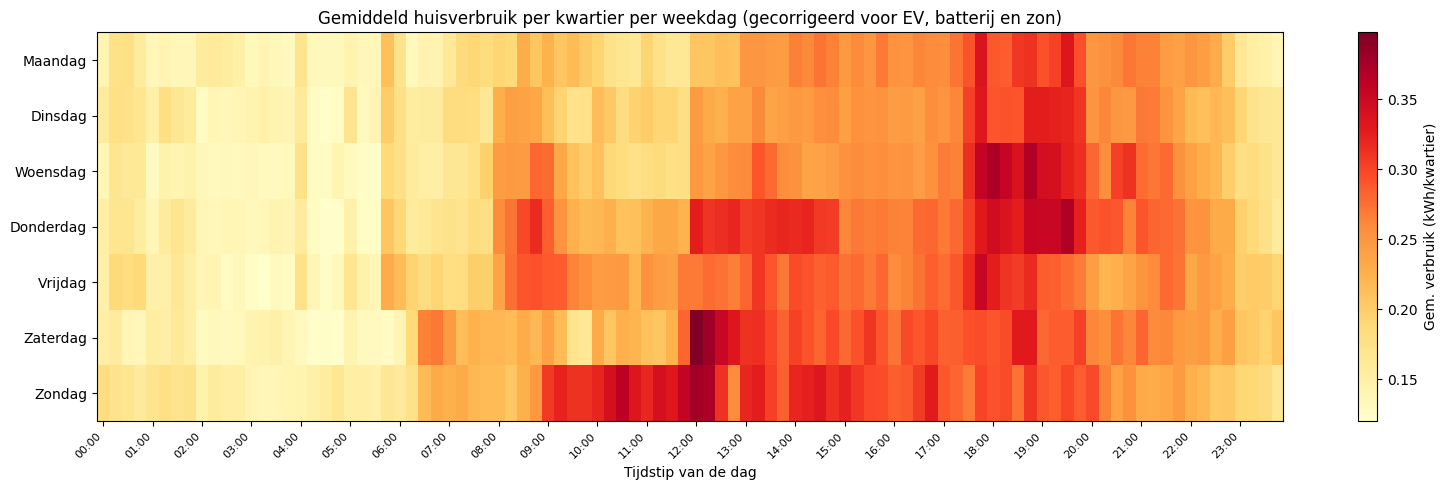

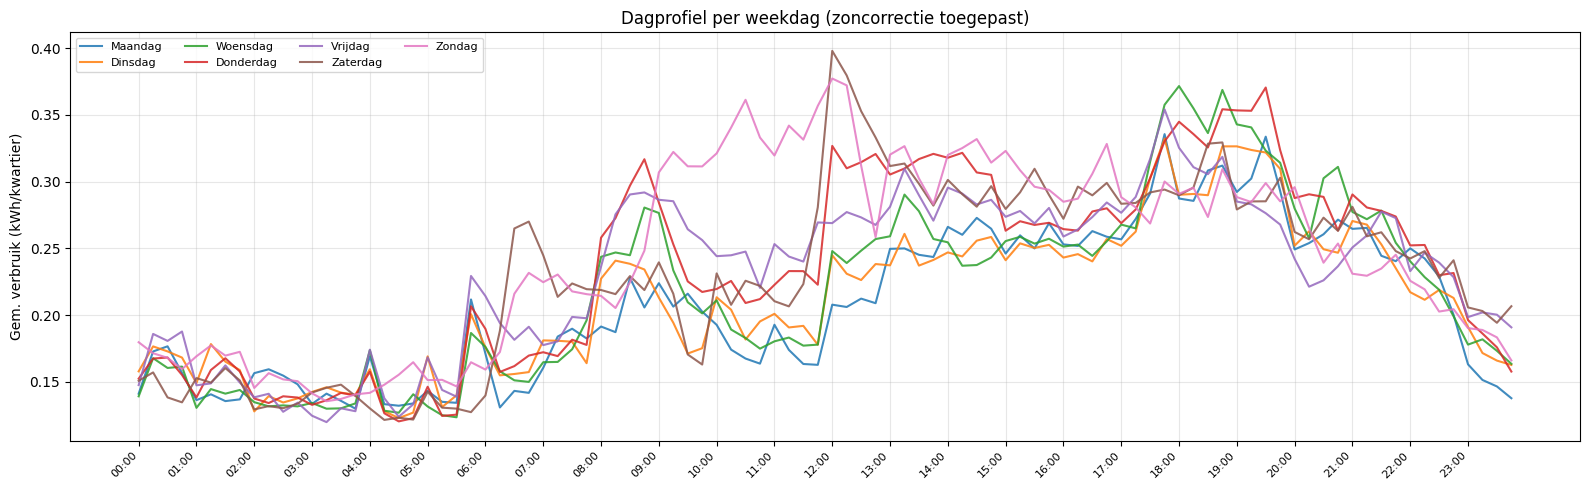

Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\weekpatroon.csv  (96 rijen x 7 weekdagen)


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

WEEKDAGEN = ['Maandag','Dinsdag','Woensdag','Donderdag','Vrijdag','Zaterdag','Zondag']

# Hulpkolommen
df['dag_van_week']    = pd.to_datetime(df['kwartier']).dt.dayofweek   # 0=ma ... 6=zo
df['kwartier_van_dag'] = (
    pd.to_datetime(df['kwartier']).dt.hour * 4
    + pd.to_datetime(df['kwartier']).dt.minute // 15
)  # 0..95

# Gemiddeld verbruik per (weekdag, kwartier van dag)
week = (
    df.groupby(['dag_van_week', 'kwartier_van_dag'])['verbruik_zon_gecorr']
    .mean()
    .unstack(level=0)   # kolommen = weekdag 0..6
)
week.columns = [WEEKDAGEN[i] for i in week.columns]

# Tijdas: kwartier 0..95 -> HH:MM labels
tijdlabels = [
    f'{h:02d}:{m:02d}'
    for h in range(24) for m in (0, 15, 30, 45)
]

# ── Tabel ────────────────────────────────────────────────────────────────
tabel = week.copy()
tabel.index = tijdlabels
print('Gemiddeld verbruik (kWh/kwartier) per weekdag en tijdstip')
print('(eerste en laatste uren getoond):')
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_columns', 10):
    display(pd.concat([tabel.head(8), tabel.iloc[44:52], tabel.tail(8)]))

# ── Heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(
    week.T.values,          # rijen = weekdagen, kolommen = kwartieren
    aspect='auto',
    cmap='YlOrRd',
    interpolation='nearest'
)
plt.colorbar(im, ax=ax, label='Gem. verbruik (kWh/kwartier)')
ax.set_yticks(range(7))
ax.set_yticklabels(WEEKDAGEN)
# X-as: elk uur een label
uur_ticks = list(range(0, 96, 4))
ax.set_xticks(uur_ticks)
ax.set_xticklabels([tijdlabels[i] for i in uur_ticks], rotation=45, ha='right', fontsize=8)
ax.set_title('Gemiddeld huisverbruik per kwartier per weekdag (gecorrigeerd voor EV, batterij en zon)')
ax.set_xlabel('Tijdstip van de dag')
plt.tight_layout()
plt.show()

# ── Lijnplot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
kleuren = plt.cm.tab10.colors
for i, dag in enumerate(WEEKDAGEN):
    ax.plot(range(96), week[dag], color=kleuren[i], lw=1.5,
            label=dag, alpha=0.85)
ax.set_xticks(uur_ticks)
ax.set_xticklabels([tijdlabels[i] for i in uur_ticks], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Gem. verbruik (kWh/kwartier)')
ax.set_title('Dagprofiel per weekdag (zoncorrectie toegepast)')
ax.legend(loc='upper left', fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Opslaan: weekpatroon ─────────────────────────────────────────────────
# Elke rij = één kwartier van de dag (0..95, = 0:00 t/m 23:45).
# Elke kolom = een weekdag (Maandag..Zondag).
# Waarden zijn het gemiddeld huisverbruik in kWh over alle gelijkaardige
# kwartieren in de dataset, gecorrigeerd voor EV en batterijherverdeling.
# Dit patroon dient als inputfeature voor vraag-voorspellingsmodellen.
from scripts.config import FINAL_DIR
pad_week = FINAL_DIR / 'weekpatroon.csv'
week_export = week.copy()
week_export.index.name = 'kwartier_van_dag'
week_export['tijdstip'] = [
    f'{h:02d}:{m:02d}' for h in range(24) for m in (0, 15, 30, 45)
]
week_export = week_export[['tijdstip'] + WEEKDAGEN]
week_export.to_csv(pad_week)
print(f'Opgeslagen: {pad_week}  ({len(week_export)} rijen x {len(WEEKDAGEN)} weekdagen)')


### Verhouding zonneschijn ↔ injectie naar het net

Omdat de SolarLogs-API geen afzonderlijke productiemeting levert (het veld
`production` is doorlopend 0), gebruiken we de **injectie naar het net**
(`injectie_kwh` uit de Fluvius-data) als proxy voor zonne-activiteit.

Die keuze is verdedigbaar:
- Bij weinig zon is de injectie (quasi) nul.
- Bij veel zon stijgt de injectie naarmate de productie de directe
  huisbehoefte overschrijdt.
- De injectie **onderschat** de werkelijke productie (zelfconsumptie is
  niet zichtbaar), maar de **rangorde** tussen zonnige en bewolkte dagen
  blijft correct.

We berekenen twee verhoudingen:

| Verhouding | Formule | Interpretatie |
|---|---|---|
| kWh injectie per zonuur | `injectie / (zon_min / 60)` | Gemiddeld injectievermogen tijdens zonneschijn |
| kWh injectie per kWh/m² POA | `injectie / poa_kwh_m2` | Injectie-rendement t.o.v. instraling |

Een hoge correlatie bevestigt dat POA-instraling bruikbaar is als proxy
voor de netto zonne-opbrengst, zelfs zonder productiemeter.


Dagen met zon en injectiedata : 465
Correlatie zonneschijnduur ↔ injectie : r = 0.407
Correlatie POA-instraling  ↔ injectie : r = 0.459

Gem. injectie per uur zonneschijn     : 0.113 kWh/uur
Gem. injectie per kWh/m² POA          : 0.229 kWh/(kWh/m²)

Regressieparameters:
  injectie = 0.0016 x zon_min    + -0.185
  injectie = 0.2261 x poa_kwh_m2 + -0.047


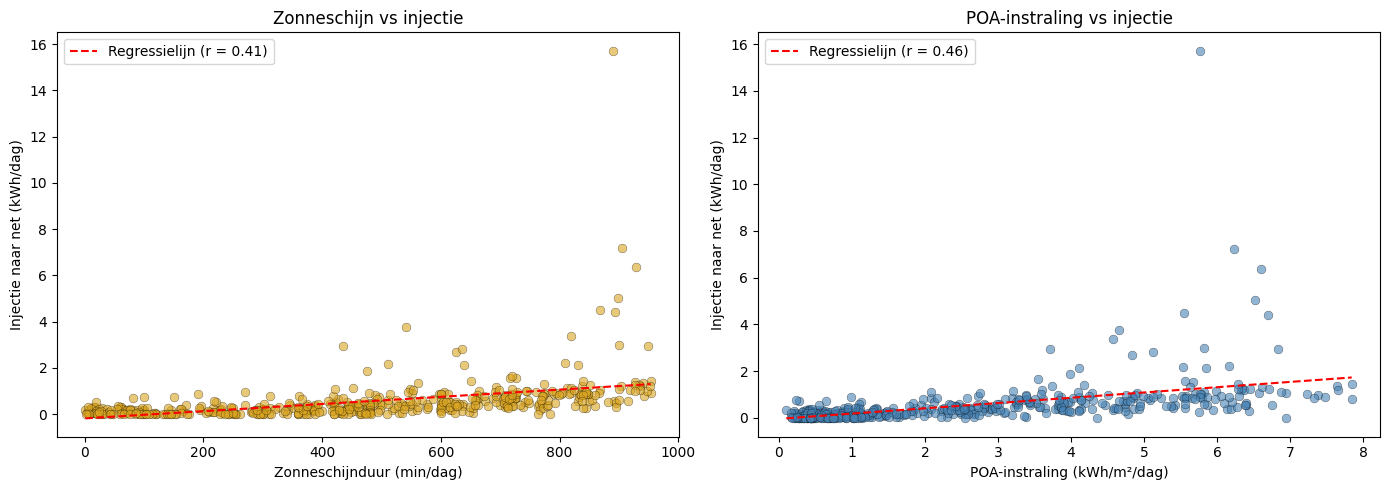

Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\dag_zon_analyse.csv  (522 rijen)
Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\dag_zon_met_verhoudingen.csv  (465 rijen)


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# dag-aggregatie aanmaken (injectie + weerdata per kalenderdag)
dag = df.groupby('datum').agg(
    injectie_kwh = ('injectie_kwh', 'sum'),
    zon_min      = ('weer_zon_min',  lambda x: x.fillna(0).sum() / 4),
    poa_kwh_m2   = ('weer_poa_w_m2', lambda x: x.fillna(0).sum() / 4 / 1000),
).round(4)

# Filter op dagen met zonneschijn én injectiedata
zon_dag = dag[
    (dag['zon_min'] > 0) &
    (dag['poa_kwh_m2'] > 0) &
    dag['injectie_kwh'].notna()
].copy()

print(f'Dagen met zon en injectiedata : {len(zon_dag)}')

if len(zon_dag) < 3:
    print()
    print('Te weinig overlappende data voor regressie.')
    print('Controleer of de weerdata en Fluvius-data dezelfde periode bestrijken.')
else:
    zon_dag['inj_per_zonuur'] = zon_dag['injectie_kwh'] / (zon_dag['zon_min'] / 60)
    zon_dag['inj_per_poa']   = zon_dag['injectie_kwh'] / zon_dag['poa_kwh_m2']

    r_zon = zon_dag['zon_min'].corr(zon_dag['injectie_kwh'])
    r_poa = zon_dag['poa_kwh_m2'].corr(zon_dag['injectie_kwh'])

    coef_zon = np.polyfit(zon_dag['zon_min'],    zon_dag['injectie_kwh'], 1)
    coef_poa = np.polyfit(zon_dag['poa_kwh_m2'], zon_dag['injectie_kwh'], 1)

    print(f'Correlatie zonneschijnduur ↔ injectie : r = {r_zon:.3f}')
    print(f'Correlatie POA-instraling  ↔ injectie : r = {r_poa:.3f}')
    print()
    print(f'Gem. injectie per uur zonneschijn     : {zon_dag["inj_per_zonuur"].mean():.3f} kWh/uur')
    print(f'Gem. injectie per kWh/m² POA          : {zon_dag["inj_per_poa"].mean():.3f} kWh/(kWh/m²)')
    print()
    print('Regressieparameters:')
    print(f'  injectie = {coef_zon[0]:.4f} x zon_min    + {coef_zon[1]:.3f}')
    print(f'  injectie = {coef_poa[0]:.4f} x poa_kwh_m2 + {coef_poa[1]:.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(zon_dag['zon_min'], zon_dag['injectie_kwh'],
               alpha=0.6, color='goldenrod', edgecolors='k', linewidths=0.3, s=40)
    x_l = np.linspace(zon_dag['zon_min'].min(), zon_dag['zon_min'].max(), 100)
    ax.plot(x_l, np.polyval(coef_zon, x_l), 'r--', lw=1.5,
            label=f'Regressielijn (r = {r_zon:.2f})')
    ax.set_xlabel('Zonneschijnduur (min/dag)')
    ax.set_ylabel('Injectie naar net (kWh/dag)')
    ax.set_title('Zonneschijn vs injectie')
    ax.legend()

    ax = axes[1]
    ax.scatter(zon_dag['poa_kwh_m2'], zon_dag['injectie_kwh'],
               alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.3, s=40)
    x_l = np.linspace(zon_dag['poa_kwh_m2'].min(), zon_dag['poa_kwh_m2'].max(), 100)
    ax.plot(x_l, np.polyval(coef_poa, x_l), 'r--', lw=1.5,
            label=f'Regressielijn (r = {r_poa:.2f})')
    ax.set_xlabel('POA-instraling (kWh/m²/dag)')
    ax.set_ylabel('Injectie naar net (kWh/dag)')
    ax.set_title('POA-instraling vs injectie')
    ax.legend()

    plt.tight_layout()
    plt.show()

# ── Opslaan: dagelijkse zon- en injectieanalyse ──────────────────────────
# Eén rij per kalenderdag met: totale injectie (kWh), zonneschijnduur (min),
# POA-instraling (kWh/m²) en de berekende verhoudingen.
# Bruikbaar als trainingsdata voor een productiemodel op dagbasis.
from scripts.config import FINAL_DIR
pad_dag = FINAL_DIR / 'dag_zon_analyse.csv'
dag_export = dag.copy()
dag_export.index.name = 'datum'
dag_export.to_csv(pad_dag)
print(f'Opgeslagen: {pad_dag}  ({len(dag_export)} rijen)')

if len(zon_dag) >= 3:
    pad_zon = FINAL_DIR / 'dag_zon_met_verhoudingen.csv'
    zon_dag.index.name = 'datum'
    zon_dag.to_csv(pad_zon)
    print(f'Opgeslagen: {pad_zon}  ({len(zon_dag)} rijen)')


### Conclusies

**Gecorrigeerd huisverbruik**

De energiebalans per kwartier houdt rekening met vier correcties op de ruwe
Fluvius-afname: EV-lading, zonne-injectie, batterijontlading (+) en
batterijlading (−). Het resultaat is het **netto huisverbruik** — de energie
die het gebouw effectief consumeert, ongeacht de bron. Kleine negatieve
waarden (meetruis, tijdsverschuiving tussen meters) worden naar nul geclipped.

**Weekpatroon**

De heatmap en het lijnplot tonen het typische 24u-verbruiksprofiel per weekdag.
Karakteristieke patronen die men kan verwachten:
- **Ochtendpiek** (6u–9u): verwarmings- en kookactiviteit;
- **Avondpiek** (17u–22u): verlichting, koken, elektrische apparaten;
- **Nachtdal** (0u–5u): enkel standby-verbruik en eventuele nachtlading van batterij;
- **Weekend vs. werkdag**: later opstaan en latere piek in de ochtend.

Afwijkingen van dit patroon kunnen wijzen op bijzondere verbruiksgebeurtenissen
(feestdagen, vakanties, warmtegolven) of op fouten in de data die verder
onderzocht moeten worden.

**Injectie als proxy voor zon**

De correlatie tussen POA-instraling en dagelijkse injectie (r ≈ 0.46) bevestigt
dat weerdata een bruikbare maar geen perfecte proxy is. De zelfconsumptie
— die niet zichtbaar is in de netmeting — verklaart de resterende variantie.


## 5. PV-opbrengst versus instraling

### Methodologie

Omdat er geen aparte productiemeter beschikbaar is, wordt de PV-opbrengst
berekend op basis van dagen **zonder batterijactiviteit**. Op die dagen
verstoort de batterij de energiebalans niet: alle productie gaat rechtstreeks
naar het huis of naar het net.

De formule per kwartier wordt dan:

```
pv_yield = injectie_kwh + basis_verbruik_kwh
```

waarbij `basis_verbruik_kwh` het **typisch verbruik** is voor dat kwartier
van de dag, berekend als mediaan van alle kwartieren zonder zon, zonder EV
en zonder batterijactiviteit. Zo wordt het verbruiksprofiel over de dag
(ochtend-, middag- en avondpatroon) bewaard in de schatting.

Vervolgens worden de kwartierwaarden per dag gesommeerd en worden de dagtotalen
gecorreleerd met de **POA-instralingsenergie per m²** (kWh/m²/dag).

Als eerste stap worden de weergegevens ververst zodat de volledige periode
van de Fluvius-data gedekt is.


In [ ]:
import scripts.weather as weather
import scripts.overall as overall
import importlib
import pandas as pd
from scripts.config import FINAL_DIR

# ── Stap 1: weerdata verversen ──────────────────────────────────────────────────────
# Bepaal de periodevan de Fluvius-data en haal weerdata op voor die volledige periode.
importlib.reload(weather)
ts_min = pd.to_datetime(df['kwartier'].min()).date()
ts_max = pd.to_datetime(df['kwartier'].max()).date()
print(f'Weerdata ophalen: {ts_min} → {ts_max} ...')
pad_weer = weather.fetch_and_save(str(ts_min), str(ts_max))
print(f'Weerdata opgeslagen: {pad_weer}')

# overall opnieuw bouwen met vernieuwde weerdata
importlib.reload(overall)
print('overall.csv herbouwen ...')
df, _ = overall.bouw()
print(f'overall.csv klaar: {len(df)} kwartieren')

# Herbereken afgeleide kolommen (ev_kwh, bat_*, verbruik_kwh, productie_geschat)
df['ev_kwh'] = df['ev_energie_kwh'].fillna(0)

def bat_kwh(kw_col, kwh_col):
    od = df[kw_col].fillna(0) * 0.25
    il = df[kwh_col].fillna(0) / 4
    return od.where(df[kw_col].notna(), il)

df['bat_ontladen_kwh_kw'] = bat_kwh('bat_ontladen_kw', 'bat_ontladen_kwh')
df['bat_laden_kwh_kw']    = bat_kwh('bat_laden_kw',    'bat_geladen_kwh')
df['verbruik_kwh'] = (
    df['afname_kwh'] + df['bat_ontladen_kwh_kw']
    - df['injectie_kwh'] - df['ev_kwh'] - df['bat_laden_kwh_kw']
).clip(lower=0)
df['poa_kwh_kw'] = df['weer_poa_w_m2'].fillna(0) * 0.25 / 1000
df['datum'] = pd.to_datetime(df['kwartier']).dt.date
df['kwartier_van_dag'] = df['kwartier'].dt.hour * 4 + df['kwartier'].dt.minute // 15
print('Afgeleide kolommen herberekend.')


Basiskwartieren (geen zon/EV/bat): 22207
Gem. basisverbruik over dag: 0.1726 kWh/kwartier = 16.57 kWh/dag

Totaal dagen in dataset         : 522
Dagen zonder batterijactiviteit : 44

Zonnige dagen zonder batterij   : 38
Correlatie POA ↔ PV-yield       : r = 0.896
Regressie: pv_yield = 2.1688 × poa + -0.089
  → systeemfactor (helling)      : 2.169 kWh/(kWh/m²)
Gem. rendement                  : 2.211 kWh/(kWh/m²)

MAANDOVERZICHT (dagen zonder batterij):
  Maand        POA kWh/m²   PV kWh   Inj. kWh Zelfcons.   Rendem.  Dagen
  --------------------------------------------------------------------
  2024-11             1.4      3.8        0.1     96.7%     2.965      3
  2025-04             1.5      5.5        0.1     98.3%     3.800      1
  2025-06             5.8     16.3       15.7      3.7%     2.827      1
  2025-09             1.4      3.9        0.2     95.2%     2.676      1
  2025-10             5.3     11.7        0.5     96.1%     2.354      4
  2025-11             4.4      8.6 

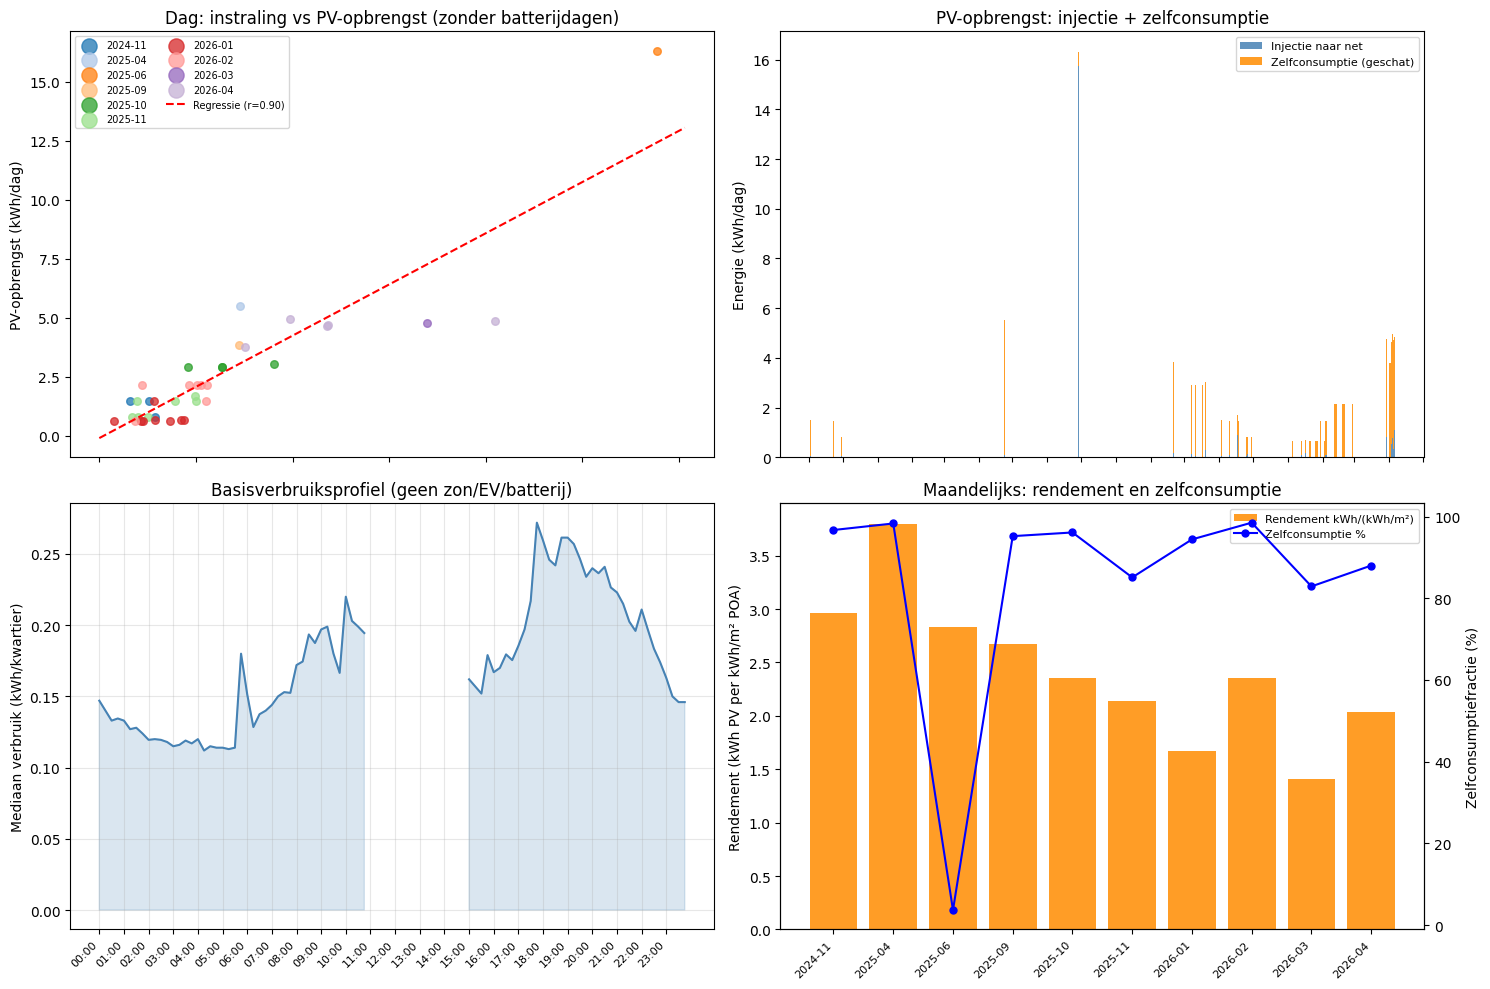


Opgeslagen: C:\Users\kurtm\Documents\V1Eindwerk\data\Final\pv_opbrengst_analyse.csv  (38 rijen)


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from scripts.config import FINAL_DIR

# Hulpkolommen opzetten als ze nog niet bestaan
# (bijv. als s5_weer niet is uitgevoerd)
if 'kwartier_van_dag' not in df.columns:
    df['kwartier_van_dag'] = (
        pd.to_datetime(df['kwartier']).dt.hour * 4
        + pd.to_datetime(df['kwartier']).dt.minute // 15
    )
if 'poa_kwh_kw' not in df.columns:
    df['poa_kwh_kw'] = df['weer_poa_w_m2'].fillna(0) * 0.25 / 1000
if 'ev_kwh' not in df.columns:
    df['ev_kwh'] = df['ev_energie_kwh'].fillna(0)
if 'datum' not in df.columns:
    df['datum'] = pd.to_datetime(df['kwartier']).dt.date
if 'bat_laden_kwh_kw' not in df.columns:
    df['bat_laden_kwh_kw'] = df.get('bat_laden_kw', pd.Series(0, index=df.index)).fillna(0) * 0.25
if 'bat_ontladen_kwh_kw' not in df.columns:
    df['bat_ontladen_kwh_kw'] = df.get('bat_ontladen_kw', pd.Series(0, index=df.index)).fillna(0) * 0.25

# ── Stap 2: basisverbruiksprofiel (geen zon, geen EV, geen batterij) ────────────
# Per kwartier van de dag: mediaan van de netafname wanneer geen enkele
# externe factor aanwezig is. Dit is het 'achtergrondverbruik' van het huis.
mask_basis = (
    (df['poa_kwh_kw'] < 0.001) &               # geen instraling
    (df['ev_kwh'] == 0) &                       # geen EV-lading
    (df['bat_laden_kwh_kw'].fillna(0) < 0.01) & # geen batterijlading
    (df['bat_ontladen_kwh_kw'].fillna(0) < 0.01) # geen batterijontlading
)
basis_profiel = (
    df[mask_basis]
    .groupby('kwartier_van_dag')['afname_kwh']
    .median()
)  # index 0..95, eenheid kWh/kwartier

print(f'Basiskwartieren (geen zon/EV/bat): {mask_basis.sum()}')
print(f'Gem. basisverbruik over dag: {basis_profiel.mean():.4f} kWh/kwartier = '
      f'{basis_profiel.mean()*96:.2f} kWh/dag')

# Wijs basisverbruik toe aan elk kwartier
df['basis_verbruik_kwh'] = df['kwartier_van_dag'].map(basis_profiel)

# ── Stap 3: dagen zonder batterijactiviteit selecteren ────────────────────────
dag_bat = df.groupby('datum').agg(
    bat_laden_kwh     = ('bat_laden_kwh_kw',    'sum'),
    bat_ontladen_kwh  = ('bat_ontladen_kwh_kw', 'sum'),
    ev_kwh            = ('ev_kwh',              'sum'),
).fillna(0)

# Drempel: minder dan 0.5 kWh totale batterijbeweging per dag
DREMPEL_BAT = 0.5
geen_bat = dag_bat[
    (dag_bat['bat_laden_kwh']    < DREMPEL_BAT) &
    (dag_bat['bat_ontladen_kwh'] < DREMPEL_BAT) &
    (dag_bat['ev_kwh']           < 0.1)
].index

print(f'\nTotaal dagen in dataset         : {dag_bat.shape[0]}')
print(f'Dagen zonder batterijactiviteit : {len(geen_bat)}')

# ── Stap 4: PV-opbrengst berekenen op die dagen ────────────────────────────
df_nb = df[df['datum'].isin(geen_bat)].copy()

# pv_yield per kwartier = injectie + basis_verbruik
# (op zonnige kwartieren; 's nachts is injectie=0 en pv_yield=basis_verbruik,
#  wat geen PV-opbrengst is maar het nachtverbruik vertegenwoordigt)
# Selecteer enkel kwartieren met instraling voor de PV-yield berekening
df_nb['pv_yield_kwh'] = (
    df_nb['injectie_kwh'] + df_nb['basis_verbruik_kwh']
).where(df_nb['poa_kwh_kw'] > 0.001, other=0)

# Dagtotalen
dag_pv = df_nb.groupby('datum').agg(
    poa_kwh_m2   = ('poa_kwh_kw',    'sum'),  # kWh/m2/dag
    pv_yield_kwh = ('pv_yield_kwh',  'sum'),
    injectie_kwh = ('injectie_kwh',  'sum'),
    n_kw         = ('kwartier',      'count'),
).round(4)
dag_pv.index = pd.to_datetime(dag_pv.index)
dag_pv['maand'] = dag_pv.index.to_period('M')

# Enkel dagen met zon (poa > 0.1 kWh/m2 en yield > 0)
dag_zon = dag_pv[(dag_pv['poa_kwh_m2'] > 0.1) & (dag_pv['pv_yield_kwh'] > 0)].copy()

# Rendement: kWh PV per kWh/m2 instraling
dag_zon['rendement'] = dag_zon['pv_yield_kwh'] / dag_zon['poa_kwh_m2']

# Regressie en correlatie
coef = np.polyfit(dag_zon['poa_kwh_m2'], dag_zon['pv_yield_kwh'], 1)
r    = dag_zon['poa_kwh_m2'].corr(dag_zon['pv_yield_kwh'])

print(f'\nZonnige dagen zonder batterij   : {len(dag_zon)}')
print(f'Correlatie POA \u2194 PV-yield       : r = {r:.3f}')
print(f'Regressie: pv_yield = {coef[0]:.4f} \u00d7 poa + {coef[1]:.3f}')
print(f'  → systeemfactor (helling)      : {coef[0]:.3f} kWh/(kWh/m\u00b2)')
print(f'Gem. rendement                  : {dag_zon["rendement"].mean():.3f} kWh/(kWh/m\u00b2)')

# Maandoverzicht
maand_tot = dag_zon.groupby('maand').agg(
    poa_kwh_m2   = ('poa_kwh_m2',   'sum'),
    pv_yield_kwh = ('pv_yield_kwh', 'sum'),
    injectie_kwh = ('injectie_kwh', 'sum'),
    rendement    = ('rendement',    'mean'),
    n_dagen      = ('pv_yield_kwh', 'count'),
).round(3)
maand_tot['zelfcons_kwh']  = (maand_tot['pv_yield_kwh'] - maand_tot['injectie_kwh']).clip(lower=0)
maand_tot['zelfcons_frac'] = (maand_tot['zelfcons_kwh'] / maand_tot['pv_yield_kwh']).round(3)

print('\nMAANDOVERZICHT (dagen zonder batterij):')
poa_hdr = "POA kWh/m²"
kop = f'  {"Maand":<10} {poa_hdr:>12} {"PV kWh":>8} {"Inj. kWh":>10} {"Zelfcons.":>9} {"Rendem.":>9} {"Dagen":>6}'
print(kop)
print('  ' + '-'*68)
for per, r_m in maand_tot.iterrows():
    print(f'  {str(per):<10} {r_m["poa_kwh_m2"]:>12.1f} {r_m["pv_yield_kwh"]:>8.1f}'
          f' {r_m["injectie_kwh"]:>10.1f} {r_m["zelfcons_frac"]:>9.1%}'
          f' {r_m["rendement"]:>9.3f} {int(r_m["n_dagen"]):>6}')

# ── Grafieken ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Scatter: POA vs PV-yield per dag (ingekleurd per maand)
ax = axes[0, 0]
kleuren = plt.cm.tab20.colors
for i, m in enumerate(sorted(dag_zon['maand'].unique())):
    sel = dag_zon[dag_zon['maand'] == m]
    ax.scatter(sel['poa_kwh_m2'], sel['pv_yield_kwh'],
               s=30, alpha=0.75, color=kleuren[i % 20], label=str(m))
x_l = np.linspace(0, dag_zon['poa_kwh_m2'].max() * 1.05, 100)
ax.plot(x_l, np.polyval(coef, x_l), 'r--', lw=1.5,
        label=f'Regressie (r={r:.2f})')
ax.set_xlabel('POA-instraling (kWh/m\u00b2/dag)')
ax.set_ylabel('PV-opbrengst (kWh/dag)')
ax.set_title('Dag: instraling vs PV-opbrengst (zonder batterijdagen)')
ax.legend(markerscale=2, fontsize=7, ncol=2, loc='upper left')

# 2. Gestapeld: PV opgesplitst in injectie + zelfconsumptie
ax = axes[0, 1]
ax.bar(dag_zon.index, dag_zon['injectie_kwh'], width=1,
       color='steelblue', alpha=0.85, label='Injectie naar net')
ax.bar(dag_zon.index, dag_zon['pv_yield_kwh'] - dag_zon['injectie_kwh'],
       bottom=dag_zon['injectie_kwh'], width=1,
       color='darkorange', alpha=0.85, label='Zelfconsumptie (geschat)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
ax.set_ylabel('Energie (kWh/dag)')
ax.set_title('PV-opbrengst: injectie + zelfconsumptie')
ax.legend(fontsize=8)

# 3. Basisverbruiksprofiel (als referentie)
ax = axes[1, 0]
tijdlabels = [f'{h:02d}:{m:02d}' for h in range(24) for m in (0,15,30,45)]
ax.plot(range(96), basis_profiel.reindex(range(96)).values,
        color='steelblue', lw=1.5)
ax.fill_between(range(96), basis_profiel.reindex(range(96)).values,
                alpha=0.2, color='steelblue')
ax.set_xticks(range(0, 96, 4))
ax.set_xticklabels([tijdlabels[i] for i in range(0, 96, 4)],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mediaan verbruik (kWh/kwartier)')
ax.set_title('Basisverbruiksprofiel (geen zon/EV/batterij)')
ax.grid(True, alpha=0.3)

# 4. Maandelijks rendement (kWh PV per kWh/m2 POA)
ax = axes[1, 1]
x_pos = range(len(maand_tot))
ax.bar(x_pos, maand_tot['rendement'], color='darkorange', alpha=0.85,
       label='Rendement kWh/(kWh/m\u00b2)')
ax2 = ax.twinx()
ax2.plot(x_pos, maand_tot['zelfcons_frac'] * 100, 'bo-', lw=1.5, ms=5,
         label='Zelfconsumptie %')
ax.set_xticks(list(x_pos))
ax.set_xticklabels([str(m) for m in maand_tot.index],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Rendement (kWh PV per kWh/m\u00b2 POA)')
ax2.set_ylabel('Zelfconsumptiefractie (%)')
ax.set_title('Maandelijks: rendement en zelfconsumptie')
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8)

plt.tight_layout()
plt.show()

# ── Opslaan ───────────────────────────────────────────────────────────────────
pad_pv = FINAL_DIR / 'pv_opbrengst_analyse.csv'
dag_zon.index.name = 'datum'
dag_zon.to_csv(pad_pv)
print(f'\nOpgeslagen: {pad_pv}  ({len(dag_zon)} rijen)')


### Conclusies PV-opbrengst

**Kwaliteit van de methode**

Door enkel dagen zonder batterijactiviteit te gebruiken, vervalt de onzekerheid
over de rol van de batterij in de energiebalans. Het basisverbruiksprofiel
per kwartier van de dag maakt de schatting tijdsgebonden: het huis verbruikt
's ochtends en 's avonds meer dan 's middags, en dat wordt in rekening gebracht.

**Rendement en regressie**

De helling van de regressielijn (`kWh PV per kWh/m² POA`) is een directe
maatstaf voor de **effectieve systeemgrootte** (paneloppervlak × efficiëntie × PR).
De intercept geeft aan hoeveel PV-energie er al aanwezig is bij minimale
instraling (diffuus licht).

**Zelfconsumptie**

Op dagen zonder batterij wordt alle geproduceerde energie die niet geïnjecteerd
wordt, direct in het huis verbruikt. De zelfconsumptiefractie varieert per
seizoen: in de winter is het verbruik hoog t.o.v. de productie (hoge fractie),
in de zomer produceert het systeem vaak meer dan het huis op dat moment
verbruikt (lagere fractie, meer injectie).

**Beperking**

Het basisverbruik is een mediaan en varieert in de werkelijkheid dag tot dag
(verwarmingsvraag, aanwezigheid, seizoen). Dagen met abnormaal hoog of laag
verbruik worden door de mediaan enigszins afgevlakt, maar introduceren ruis
in de PV-yield schatting.
